In [32]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import math
import seaborn as sns

sccoda_model = pt.tl.Sccoda()

In [2]:
adata_age_cd8= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_cd8

AnnData object with n_obs × n_vars = 248612 × 2889
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collect

In [4]:
adata_age_cd8.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      57390
4–6      60061
7–10     38486
11–14    68909
15–18    23766
Name: count, dtype: int64

In [5]:
adata_age_cd8.obs['cell_type'].unique()
adata_age_cd8.obs['cell_type'].value_counts()

cell_type
Naive/Central memory CD8 T cell      164455
CD8+ gdT cell                         21412
GZMK+ CD8 T cell                      14741
CD8 Temra                             13162
TOX+ CD8 T cell                       10777
CD27+ CCR7+ suppressed CD8 T cell     10741
CD27- CCR7- suppressed CD8 T cell      9596
CD27+ CCR7- suppressed CD8 T cell      2749
Suppressed CD8 T cell                   693
Inhibitory KIR+ CD8 T cell              220
CD8 TEM                                  46
GZMK+ memory CD8 T cell                  13
Efector memory CD8 T cell                 7
Name: count, dtype: int64

In [6]:
adata_age_cd8.obs["Age_group"] = pd.Categorical(
        adata_age_cd8.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )


In [7]:
adata_age_cd8.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      57390
4–6      60061
7–10     38486
11–14    68909
15–18    23766
Name: count, dtype: int64

In [8]:
adata_age_cd8.obs["Child's sex"] = adata_age_cd8.obs["Child's sex"].astype("category")

In [9]:
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="cell_type",   
    sample_col="pica_id",       
    covariates=("Age_group","Child's sex"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data

In [11]:
sccoda_cd8 = make_sccoda_from_lineage(adata_age_cd8, cell_type_col="cell_type")
sccoda_cd8

MuData object with n_obs × n_vars = 248740 × 2902
  2 modalities
    rna:	248612 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_pca', 'X_scVI', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	128 x 13
      obs:	'

### Age only model

In [12]:
# prepare sccoda model
def prepare_sccoda_age(sccoda_data, modality_key="coda"):
    # formula in patsy/R style: here only Age_group, but you can add + sex etc
    formula = "Age_group"

    sccoda_data = sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type="automatic", 
    )
    return sccoda_data

In [13]:
sccoda_cd8 = prepare_sccoda_age(sccoda_cd8)

• Automatic reference selection! Reference cell type set to Naive/Central memory CD8 T cell
• Zero counts encountered in data! Added a pseudocount of 0.5.


In [14]:
# run sccoda
def run_sccoda(sccoda_data, modality_key="coda", rng_key=0):
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key=modality_key,
        num_warmup=2000,
        num_samples=5000,
        rng_key=rng_key,
    )
    return sccoda_data


In [15]:
sccoda_cd8 = run_sccoda(sccoda_cd8, rng_key=1)

sample: 100%|██████████| 7000/7000 [04:09<00:00, 28.05it/s, 127 steps of size 3.40e-02. acc. prob=0.77]


In [16]:
sccoda_model.summary(sccoda_cd8, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 13 cell types                                        │
│ Reference cell type                   │ Naive/Central memory CD8 T cell                                         │
│ Formula                               │ Age_group                                                               │
│ Reference index                       │ 10                                                                      │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 76.6%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                      │
│ cell_type                                                                                                       │
│ CD8 TEM                                -1.840       -2.018  -1.652  0.097       41.340                          │
│ CD8 Temra                              -1.532       -1.726  -1.348  0.102       56.252                          │
│ CD8+ gdT cell                          -1.309       -1.518  -1.099  0.113       70.305                          │
│ CD27+ CCR7+ suppressed CD8 T cell      -1.224       -1.454  -1.021  0.113       76.542                          │
│ CD27+ CCR7- suppressed CD8 T cell      -1.700       -1.890  -1.520  0.099       47.553                          │
│ CD27- CCR7- suppressed CD8 T cell      -1.666       -1.851  -1.486  0.098       49.197                          │
│ Efector memory CD8 T cell              -1.878       -2.051  -1.698  0.095       39.799                          │
│ GZMK+ CD8 T cell                       -1.284       -1.488  -1.080  0.109       72.084                          │
│ GZMK+ memory CD8 T cell                -1.868       -2.053  -1.677  0.100       40.199                          │
│ Inhibitory KIR+ CD8 T cell             -1.797       -1.979  -1.618  0.097       43.157                          │
│ Naive/Central memory CD8 T cell         1.613        1.477   1.740  0.070     1306.146                          │
│ Suppressed CD8 T cell                  -1.831       -2.014  -1.653  0.096       41.714                          │
│ TOX+ CD8 T cell                        -1.426       -1.608  -1.238  0.099       62.542                          │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                     Final Parameter  Expected Sample  log2-fold change          │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   CD8 TEM                                0.000             41.340           0.000                │
│                  CD8 Temra                              0.000             56.252           0.000                │
│                  CD8+ gdT cell                          0.000             70.305           0.000                │
│                  CD27+ CCR7+ suppressed CD8 T cell      0.000             76.542           0.000                │
│                  CD27+ CCR7- suppressed CD8 T cell      0.000             47.553           0.000                │
│                  CD27- CCR7- suppressed CD8 T cell      0.000             49.197           0.000                │
│                  Efector memory CD8 T cell              0.000             39.799           0.000                │
│                  GZMK+ CD8 T cell                       0.000             72.084           0.000                │
│                  GZMK+ memory CD8 T cell                0.000             40.199           0.000                │
│                  Inhibitory KIR+ CD8 T cell             0.000             43.157           0.000                │
│                  Naive/Central memory CD8 T cell        0.000           1306.146           0.000                │
│                  Suppressed CD8 T cell                  0.000             41.714           0.000                │
│                  TOX+ CD8 T cell                        0.000             62.542           0.000                │
│ Age_groupT.7–10  CD8 TEM                                0.000             41.340           0.000                │
│                  CD8 Temra                              0.000             56.252           0.000                │
│                  CD8+ gdT cell                          0.000             70.305           0.000                │
│                  CD27+ CCR7+ suppressed CD8 T cell      0.000             76.542           0.000                │
│                  CD27+ CCR7- suppressed CD8 T cell      0.000             47.553           0.000                │
│                  CD27- CCR7- suppressed CD8 T cell      0.000             49.197           0.000                │
│                  Efector memory CD8 T cell              0.000             39.799           0.000                │
│                  GZMK+ CD8 T cell                       0.000             72.084           0.000                │
│                  GZMK+ memory CD8 T cell                0.000             40.199           0.000                │
│                  Inhibitory KIR+ CD8 T cell             0.000             43.157           0.000                │
│                  Naive/Central memory CD8 T cell        0.000           1306.146           0.000                │
│                  Suppressed CD8 T cell                  0.000             41.714           0.000                │
│                  TOX+ CD8 T cell                        0.000             62.542           0.000                │
│ Age_groupT.11–14 CD8 TEM                                0.000             41.340           0.000                │
│                  CD8 Temra                              0.000             56.252           0.000                │
│                  CD8+ gdT cell                          0.000             70.305           0.000                │
│                  CD27+ CCR7+ suppressed CD8 T cell    

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                     HDI 3%  HDI 97%   SD   Inclusion probability                │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   CD8 TEM                            -0.182  0.183   0.064         0.465                         │
│                  CD8 Temra                          -0.186  0.170   0.063         0.480                         │
│                  CD8+ gdT cell                      -0.144  0.262   0.079         0.497                         │
│                  CD27+ CCR7+ suppressed CD8 T cell  -0.139  0.229   0.067         0.488                         │
│                  CD27+ CCR7- suppressed CD8 T cell  -0.209  0.165   0.068         0.487                         │
│                  CD27- CCR7- suppressed CD8 T cell  -0.196  0.169   0.067         0.493                         │
│                  Efector memory CD8 T cell          -0.178  0.181   0.065         0.478                         │
│                  GZMK+ CD8 T cell                   -0.202  0.176   0.066         0.475                         │
│                  GZMK+ memory CD8 T cell            -0.220  0.150   0.068         0.488                         │
│                  Inhibitory KIR+ CD8 T cell         -0.204  0.173   0.066         0.483                         │
│                  Naive/Central memory CD8 T cell     0.000  0.000   0.000         0.000                         │
│                  Suppressed CD8 T cell              -0.232  0.165   0.069         0.483                         │
│                  TOX+ CD8 T cell                    -0.224  0.151   0.068         0.481                         │
│ Age_groupT.7–10  CD8 TEM                            -0.324  0.345   0.110         0.422                         │
│                  CD8 Temra                          -0.164  0.529   0.167         0.537                         │
│                  CD8+ gdT cell                      -0.646  0.087   0.211         0.639                         │
│                  CD27+ CCR7+ suppressed CD8 T cell  -0.653  0.082   0.207         0.631                         │
│                  CD27+ CCR7- suppressed CD8 T cell  -0.357  0.295   0.111         0.424                         │
│                  CD27- CCR7- suppressed CD8 T cell  -0.347  0.276   0.105         0.431                         │
│                  Efector memory CD8 T cell          -0.322  0.303   0.103         0.410                         │
│                  GZMK+ CD8 T cell                   -0.040  0.906   0.298         0.838                         │
│                  GZMK+ memory CD8 T cell            -0.308  0.346   0.111         0.425                         │
│                  Inhibitory KIR+ CD8 T cell         -0.268  0.402   0.117         0.432                         │
│                  Naive/Central memory CD8 T cell     0.000  0.000   0.000         0.000                         │
│                  Suppressed CD8 T cell              -0.342  0.289   0.104         0.409                         │
│                  TOX+ CD8 T cell                    -0.241  0.417   0.124         0.453                         │
│ Age_groupT.11–14 CD8 TEM                            -0.254  0.210   0.079         0.448                         │
│                  CD8 Temra                          -0.381  0.129   0.113         0.518                         │
│                  CD8+ gdT cell                      -0.098  0.479   0.139         0.573                         │
│                  CD27+ CCR7+ suppressed CD8 T cell  -0

In [17]:
# set desired FDR globally
sccoda_model.set_fdr(sccoda_cd8, est_fdr=0.1, modality_key="coda")

In [18]:
# check threshold
sccoda_cd8["coda"].uns["scCODA_params"]["threshold_prob"]

1.0

In [20]:
effects_cd8 = sccoda_model.get_effect_df(sccoda_cd8, modality_key="coda")

effects_cd8["Inclusion probability"].max()
effects_cd8["Inclusion probability"].describe()

count    52.000000
mean      0.455388
std       0.149280
min       0.000000
25%       0.451750
50%       0.479600
75%       0.489950
max       0.838000
Name: Inclusion probability, dtype: float64

In [22]:
# effects dataframe
effects_cd8 = sccoda_model.get_effect_df(sccoda_cd8, modality_key="coda")
effects_cd8.head()

Final Parameter  HDI 3%  \
Covariate      Cell Type                                                    
Age_groupT.4–6 CD8 TEM                                        0.0  -0.182   
               CD8 Temra                                      0.0  -0.186   
               CD8+ gdT cell                                  0.0  -0.144   
               CD27+ CCR7+ suppressed CD8 T cell              0.0  -0.139   
               CD27+ CCR7- suppressed CD8 T cell              0.0  -0.209   

                                                  HDI 97%     SD  \
Covariate      Cell Type                                           
Age_groupT.4–6 CD8 TEM                              0.183  0.064   
               CD8 Temra                            0.170  0.063   
               CD8+ gdT cell                        0.262  0.079   
               CD27+ CCR7+ suppressed CD8 T cell    0.229  0.067   
               CD27+ CCR7- suppressed CD8 T cell    0.165  0.068   

                                                  Inclusion probability  \
Covariate      Cell Type                                                  
Age_groupT.4–6 CD8 TEM                                           0.4646   
               CD8 Temra                                         0.4796   
               CD8+ gdT cell                                     0.4968   
               CD27+ CCR7+ suppressed CD8 T cell                 0.4876   
               CD27+ CCR7- suppressed CD8 T cell                 0.4866   

                                                  Expected Sample  \
Covariate      Cell Type                                            
Age_groupT.4–6 CD8 TEM                                  41.340227   
               CD8 Temra                                56.251688   
               CD8+ gdT cell                            70.304517   
               CD27+ CCR7+ suppressed CD8 T cell        76.541728   
               CD27+ CCR7- suppressed CD8 T cell        47.552580   

                                                  log2-fold change  
Covariate      Cell Type                                            
Age_groupT.4–6 CD8 TEM                                         0.0  
               CD8 Temra                                       0.0  
               CD8+ gdT cell                                   0.0  
               CD27+ CCR7+ suppressed CD8 T cell               0.0  
               CD27+ CCR7- suppressed CD8 T cell               0.0

In [23]:
# counts per sample x celltype
counts = pd.DataFrame(
    sccoda_cd8["coda"].X,
    index=sccoda_cd8["coda"].obs_names,
    columns=sccoda_cd8["coda"].var_names,
)

# convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = sccoda_cd8["coda"].obs.copy()

# long format for plotting
df = (
    props.join(meta["Age_group"])
    .reset_index(names="sample")
    .melt(id_vars=["sample", "Age_group"], var_name="Cell Type", value_name="Proportion")
)

In [24]:
df["Cell Type"].unique()

array(['CD8 TEM', 'CD8 Temra', 'CD8+ gdT cell',
       'CD27+ CCR7+ suppressed CD8 T cell',
       'CD27+ CCR7- suppressed CD8 T cell',
       'CD27- CCR7- suppressed CD8 T cell', 'Efector memory CD8 T cell',
       'GZMK+ CD8 T cell', 'GZMK+ memory CD8 T cell',
       'Inhibitory KIR+ CD8 T cell', 'Naive/Central memory CD8 T cell',
       'Suppressed CD8 T cell', 'TOX+ CD8 T cell'], dtype=object)

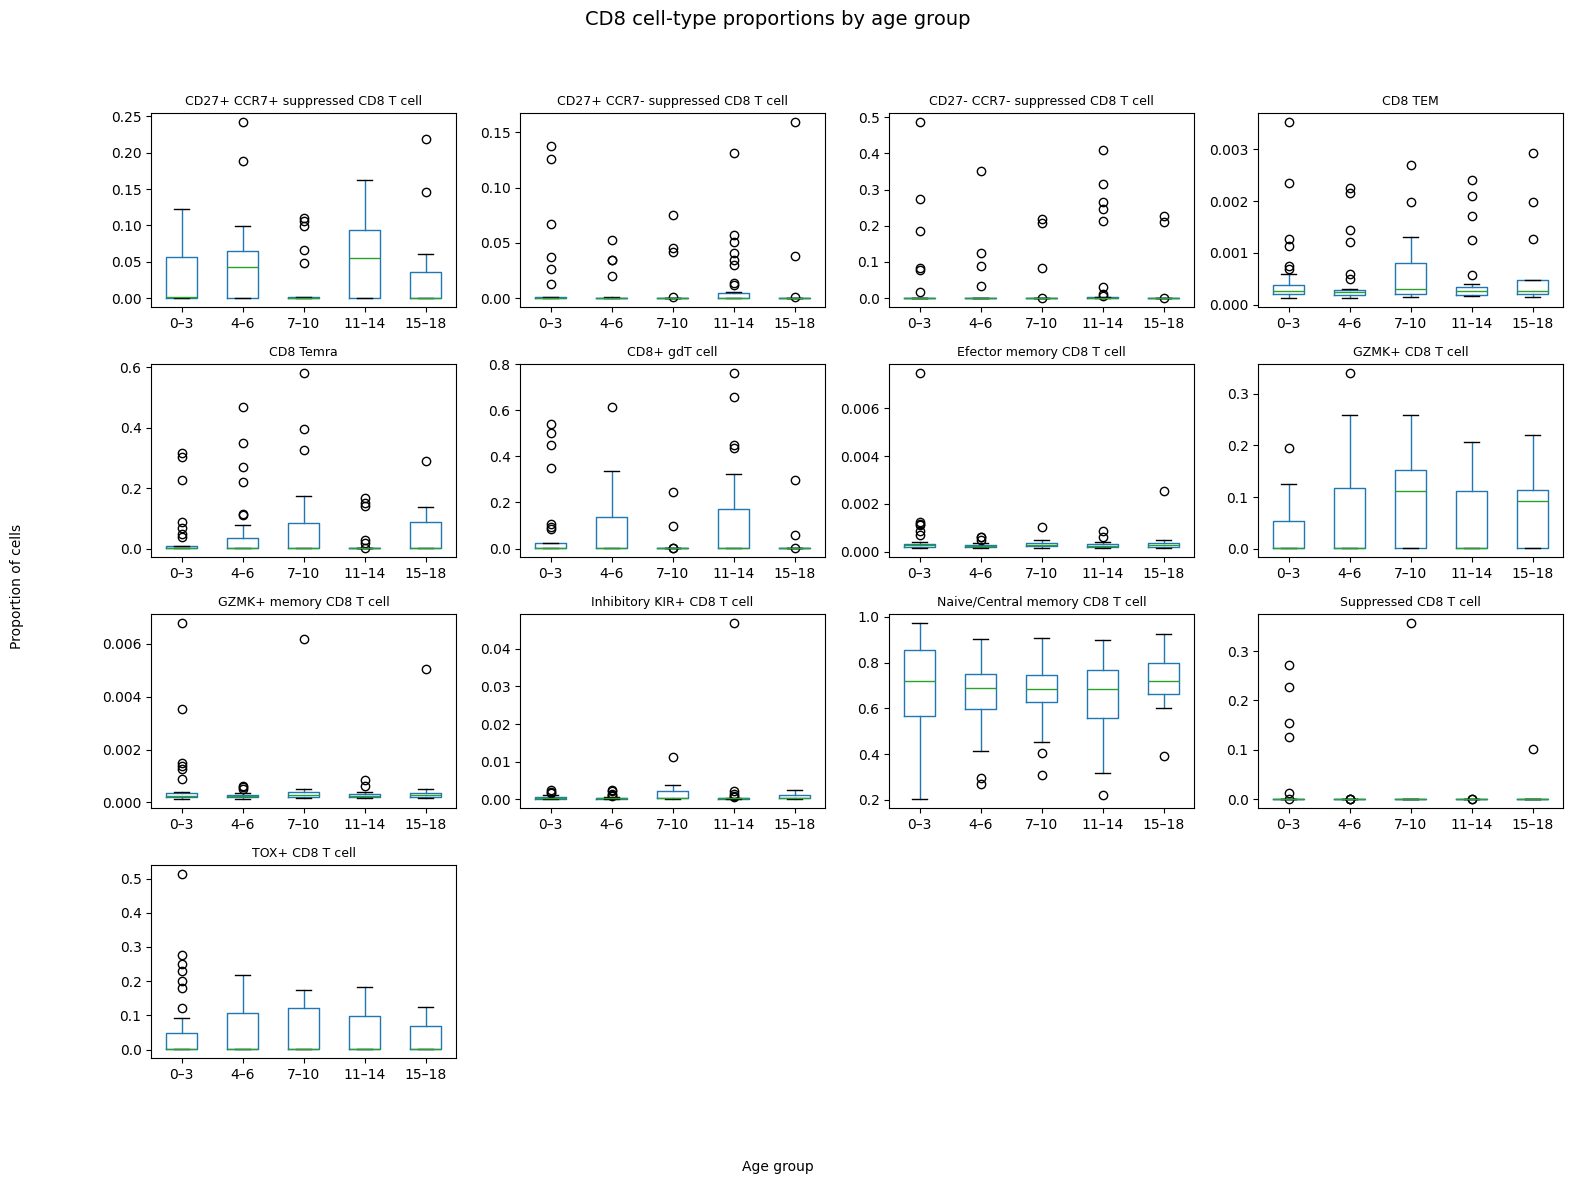

In [25]:
# boxplots of relative abundances per donor per age group
cell_types = sorted(df["Cell Type"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df[df["Cell Type"] == cell]
    sub.boxplot(
        column="Proportion",
        by="Age_group",
        grid=False,
        ax=ax
    )
    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty panels
for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("CD8 cell-type proportions by age group", fontsize=14)
fig.supxlabel("Age group", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

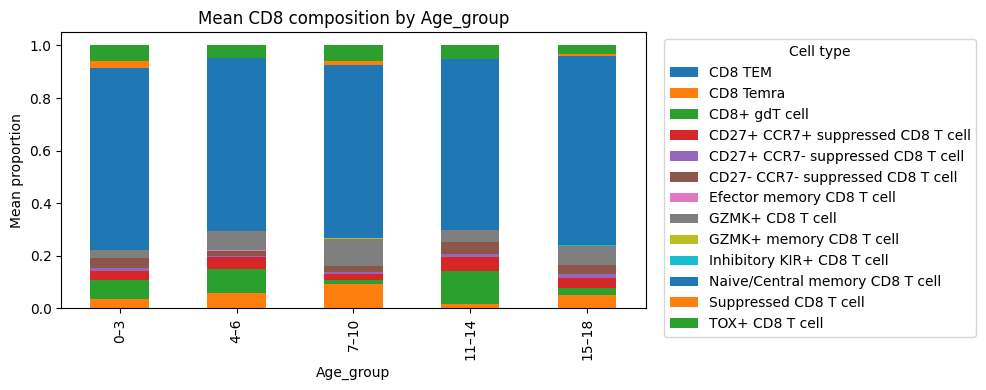

In [26]:
# barplot of composition by age group
props_age = props.join(meta["Age_group"]).groupby("Age_group").mean()

ax = props_age.plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_xlabel("Age_group")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean CD8 composition by Age_group")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
plt.tight_layout()
plt.show()

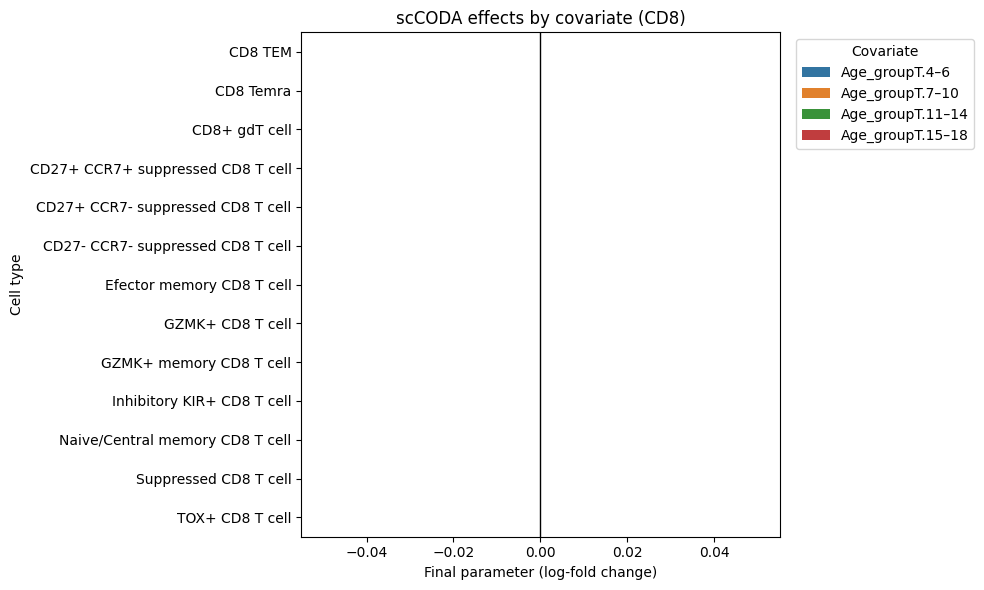

In [33]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd8,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD8)")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

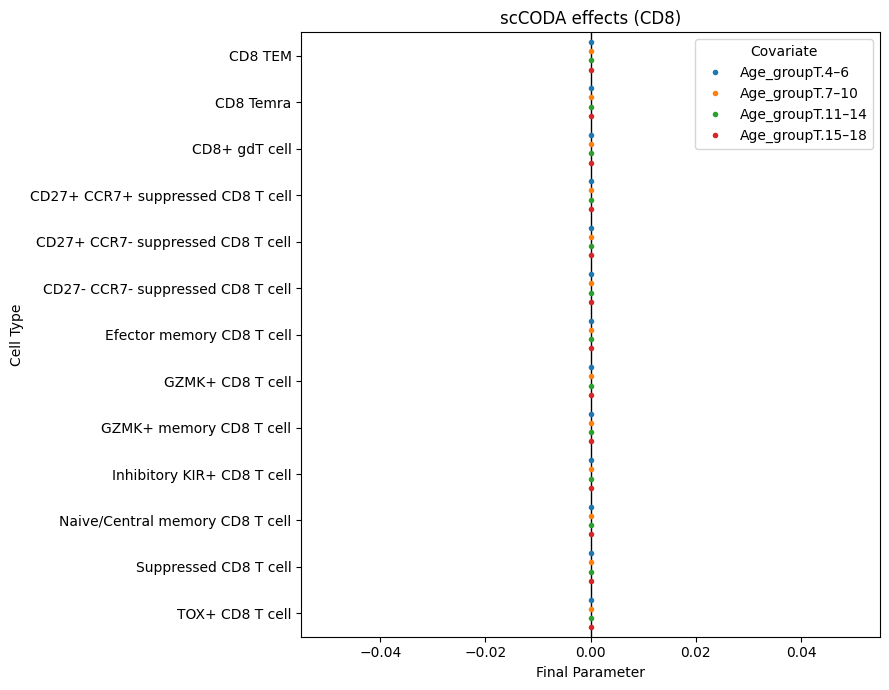

In [34]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd8,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD8)")
plt.tight_layout()
plt.show()

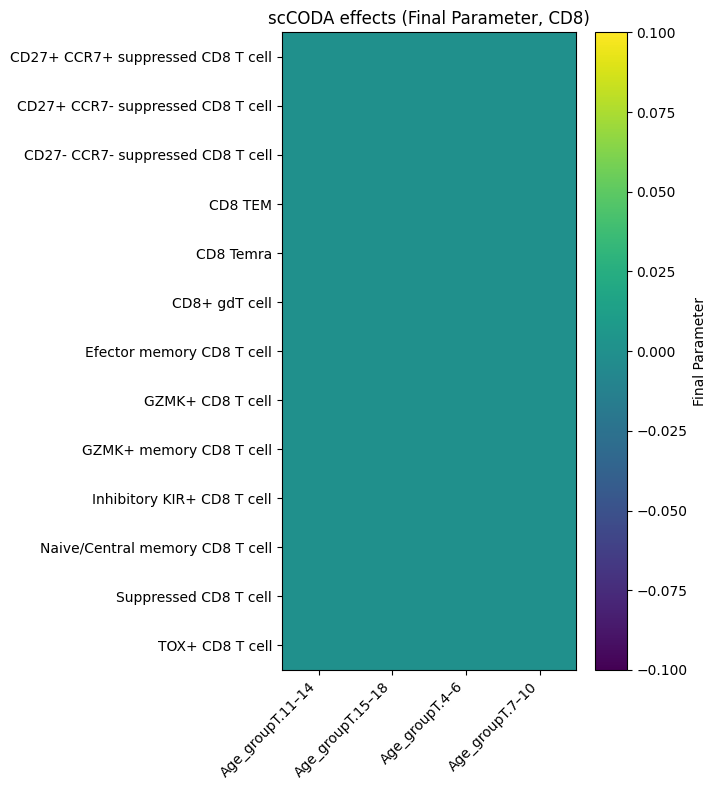

In [29]:
# inclusion pronbability heatmap
tmp = effects_cd8.reset_index()
ip = tmp.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta = effects_cd8["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta.values, aspect="auto")
plt.yticks(range(beta.shape[0]), beta.index)
plt.xticks(range(beta.shape[1]), beta.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD8)")
plt.tight_layout()
plt.show()

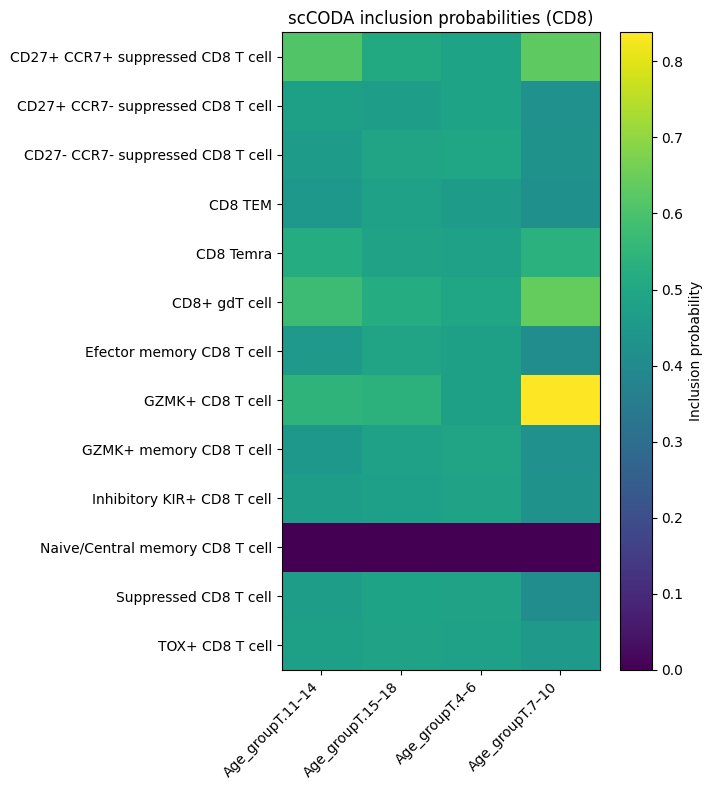

In [30]:
ip = effects_cd8["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip.values, aspect="auto")
plt.yticks(range(ip.shape[0]), ip.index)
plt.xticks(range(ip.shape[1]), ip.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD8)")
plt.tight_layout()
plt.show()

### Age + sex model

In [31]:
sccoda_cd8["coda"].obs.columns

Index(['pica_id', 'Child's sex', 'Age_group'], dtype='object')

In [35]:
sccoda_cd8["coda"].obs = sccoda_cd8["coda"].obs.rename(columns={"Child's sex": "Child_sex"})


In [36]:
# prepare sccoda model
def prepare_sccoda_age_sex(sccoda_data, modality_key="coda"):
    formula = "Age_group + Child_sex"
    return sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type="automatic",
    )
    return sccoda_data

In [37]:
sccoda_cd8_age_sex = sccoda_cd8.copy()

In [38]:
## run sccoda
sccoda_cd8_age_sex = prepare_sccoda_age_sex(sccoda_cd8)
sccoda_cd8_age_sex = run_sccoda(sccoda_cd8_age_sex, rng_key=1)

• Automatic reference selection! Reference cell type set to CD8 TEM


sample: 100%|██████████| 7000/7000 [06:22<00:00, 18.28it/s, 255 steps of size 2.27e-02. acc. prob=0.83] 


In [39]:
sccoda_model.summary(sccoda_cd8_age_sex, modality_key="coda", extended=True)
effects_cd8_age_sex = sccoda_model.get_effect_df(sccoda_cd8_age_sex, modality_key="coda")
effects_cd8_age_sex.head()

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 13 cell types                                        │
│ Reference cell type                   │ CD8 TEM                                                                 │
│ Formula                               │ Age_group + Child_sex                                                   │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 83.2%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                      │
│ cell_type                                                                                                       │
│ CD8 TEM                                -1.837       -2.014  -1.671  0.091       41.498                          │
│ CD8 Temra                              -1.556       -1.772  -1.319  0.120       54.962                          │
│ CD8+ gdT cell                          -1.284       -1.524  -1.049  0.126       72.143                          │
│ CD27+ CCR7+ suppressed CD8 T cell      -1.132       -1.425  -0.856  0.154       83.986                          │
│ CD27+ CCR7- suppressed CD8 T cell      -1.684       -1.901  -1.488  0.110       48.359                          │
│ CD27- CCR7- suppressed CD8 T cell      -1.649       -1.852  -1.434  0.111       50.081                          │
│ Efector memory CD8 T cell              -1.882       -2.079  -1.678  0.108       39.672                          │
│ GZMK+ CD8 T cell                       -1.338       -1.616  -1.086  0.140       68.350                          │
│ GZMK+ memory CD8 T cell                -1.873       -2.092  -1.687  0.108       40.031                          │
│ Inhibitory KIR+ CD8 T cell             -1.807       -2.010  -1.607  0.108       42.762                          │
│ Naive/Central memory CD8 T cell         1.607        1.449   1.767  0.085     1299.387                          │
│ Suppressed CD8 T cell                  -1.842       -2.040  -1.639  0.107       41.291                          │
│ TOX+ CD8 T cell                        -1.399       -1.602  -1.163  0.117       64.306                          │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                     Final Parameter  Expected Sample  log2-fold change          │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   CD8 TEM                                0.000             41.498           0.000                │
│                  CD8 Temra                              0.000             54.962           0.000                │
│                  CD8+ gdT cell                          0.000             72.143           0.000                │
│                  CD27+ CCR7+ suppressed CD8 T cell      0.000             83.986           0.000                │
│                  CD27+ CCR7- suppressed CD8 T cell      0.000             48.359           0.000                │
│                  CD27- CCR7- suppressed CD8 T cell      0.000             50.081           0.000                │
│                  Efector memory CD8 T cell              0.000             39.672           0.000                │
│                  GZMK+ CD8 T cell                       0.000             68.350           0.000                │
│                  GZMK+ memory CD8 T cell                0.000             40.031           0.000                │
│                  Inhibitory KIR+ CD8 T cell             0.000             42.762           0.000                │
│                  Naive/Central memory CD8 T cell        0.000           1299.387           0.000                │
│                  Suppressed CD8 T cell                  0.000             41.291           0.000                │
│                  TOX+ CD8 T cell                        0.000             64.306           0.000                │
│ Age_groupT.7–10  CD8 TEM                                0.000             41.498           0.000                │
│                  CD8 Temra                              0.000             54.962           0.000                │
│                  CD8+ gdT cell                          0.000             72.143           0.000                │
│                  CD27+ CCR7+ suppressed CD8 T cell      0.000             83.986           0.000                │
│                  CD27+ CCR7- suppressed CD8 T cell      0.000             48.359           0.000                │
│                  CD27- CCR7- suppressed CD8 T cell      0.000             50.081           0.000                │
│                  Efector memory CD8 T cell              0.000             39.672           0.000                │
│                  GZMK+ CD8 T cell                       0.000             68.350           0.000                │
│                  GZMK+ memory CD8 T cell                0.000             40.031           0.000                │
│                  Inhibitory KIR+ CD8 T cell             0.000             42.762           0.000                │
│                  Naive/Central memory CD8 T cell        0.000           1299.387           0.000                │
│                  Suppressed CD8 T cell                  0.000             41.291           0.000                │
│                  TOX+ CD8 T cell                        0.000             64.306           0.000                │
│ Age_groupT.11–14 CD8 TEM                                0.000             41.498           0.000                │
│                  CD8 Temra                              0.000             54.962           0.000                │
│                  CD8+ gdT cell                          0.000             72.143           0.000                │
│                  CD27+ CCR7+ suppressed CD8 T cell    

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                     HDI 3%  HDI 97%   SD   Inclusion probability                │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   CD8 TEM                             0.000  0.000   0.000         0.000                         │
│                  CD8 Temra                          -0.202  0.167   0.066         0.483                         │
│                  CD8+ gdT cell                      -0.135  0.252   0.079         0.492                         │
│                  CD27+ CCR7+ suppressed CD8 T cell  -0.165  0.210   0.068         0.481                         │
│                  CD27+ CCR7- suppressed CD8 T cell  -0.225  0.153   0.069         0.489                         │
│                  CD27- CCR7- suppressed CD8 T cell  -0.210  0.147   0.067         0.491                         │
│                  Efector memory CD8 T cell          -0.191  0.176   0.065         0.474                         │
│                  GZMK+ CD8 T cell                   -0.195  0.201   0.067         0.462                         │
│                  GZMK+ memory CD8 T cell            -0.189  0.161   0.064         0.483                         │
│                  Inhibitory KIR+ CD8 T cell         -0.209  0.160   0.066         0.487                         │
│                  Naive/Central memory CD8 T cell    -0.160  0.141   0.054         0.465                         │
│                  Suppressed CD8 T cell              -0.201  0.161   0.066         0.476                         │
│                  TOX+ CD8 T cell                    -0.228  0.146   0.070         0.488                         │
│ Age_groupT.7–10  CD8 TEM                             0.000  0.000   0.000         0.000                         │
│                  CD8 Temra                          -0.158  0.609   0.180         0.529                         │
│                  CD8+ gdT cell                      -0.675  0.075   0.214         0.627                         │
│                  CD27+ CCR7+ suppressed CD8 T cell  -0.660  0.092   0.218         0.649                         │
│                  CD27+ CCR7- suppressed CD8 T cell  -0.337  0.302   0.107         0.412                         │
│                  CD27- CCR7- suppressed CD8 T cell  -0.370  0.265   0.109         0.424                         │
│                  Efector memory CD8 T cell          -0.286  0.336   0.108         0.414                         │
│                  GZMK+ CD8 T cell                   -0.017  0.947   0.311         0.844                         │
│                  GZMK+ memory CD8 T cell            -0.304  0.348   0.107         0.401                         │
│                  Inhibitory KIR+ CD8 T cell         -0.241  0.392   0.111         0.426                         │
│                  Naive/Central memory CD8 T cell    -0.278  0.244   0.084         0.379                         │
│                  Suppressed CD8 T cell              -0.318  0.323   0.106         0.412                         │
│                  TOX+ CD8 T cell                    -0.249  0.403   0.119         0.434                         │
│ Age_groupT.11–14 CD8 TEM                             0.000  0.000   0.000         0.000                         │
│                  CD8 Temra                          -0.382  0.143   0.117         0.537                         │
│                  CD8+ gdT cell                      -0.104  0.471   0.139         0.567                         │
│                  CD27+ CCR7+ suppressed CD8 T cell  -0

Final Parameter  HDI 3%  \
Covariate      Cell Type                                                    
Age_groupT.4–6 CD8 TEM                                        0.0   0.000   
               CD8 Temra                                      0.0  -0.202   
               CD8+ gdT cell                                  0.0  -0.135   
               CD27+ CCR7+ suppressed CD8 T cell              0.0  -0.165   
               CD27+ CCR7- suppressed CD8 T cell              0.0  -0.225   

                                                  HDI 97%     SD  \
Covariate      Cell Type                                           
Age_groupT.4–6 CD8 TEM                              0.000  0.000   
               CD8 Temra                            0.167  0.066   
               CD8+ gdT cell                        0.252  0.079   
               CD27+ CCR7+ suppressed CD8 T cell    0.210  0.068   
               CD27+ CCR7- suppressed CD8 T cell    0.153  0.069   

                                                  Inclusion probability  \
Covariate      Cell Type                                                  
Age_groupT.4–6 CD8 TEM                                           0.0000   
               CD8 Temra                                         0.4826   
               CD8+ gdT cell                                     0.4922   
               CD27+ CCR7+ suppressed CD8 T cell                 0.4814   
               CD27+ CCR7- suppressed CD8 T cell                 0.4894   

                                                  Expected Sample  \
Covariate      Cell Type                                            
Age_groupT.4–6 CD8 TEM                                  41.498109   
               CD8 Temra                                54.962321   
               CD8+ gdT cell                            72.142828   
               CD27+ CCR7+ suppressed CD8 T cell        83.985811   
               CD27+ CCR7- suppressed CD8 T cell        48.358784   

                                                  log2-fold change  
Covariate      Cell Type                                            
Age_groupT.4–6 CD8 TEM                                         0.0  
               CD8 Temra                                       0.0  
               CD8+ gdT cell                                   0.0  
               CD27+ CCR7+ suppressed CD8 T cell               0.0  
               CD27+ CCR7- suppressed CD8 T cell               0.0

In [40]:
# counts per sample x celltype
counts = pd.DataFrame(
    sccoda_cd8_age_sex["coda"].X,
    index=sccoda_cd8_age_sex["coda"].obs_names,
    columns=sccoda_cd8_age_sex["coda"].var_names,
)

# convert to proportions per sample (row)
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = sccoda_cd8_age_sex["coda"].obs.copy()

df_age_sex = (
    props
    .join(meta[["Age_group", "Child_sex"]])   
    .reset_index(names="sample")
    .melt(
        id_vars=["sample", "Age_group", "Child_sex"],  
        var_name="Cell Type",
        value_name="Proportion",
    )
)

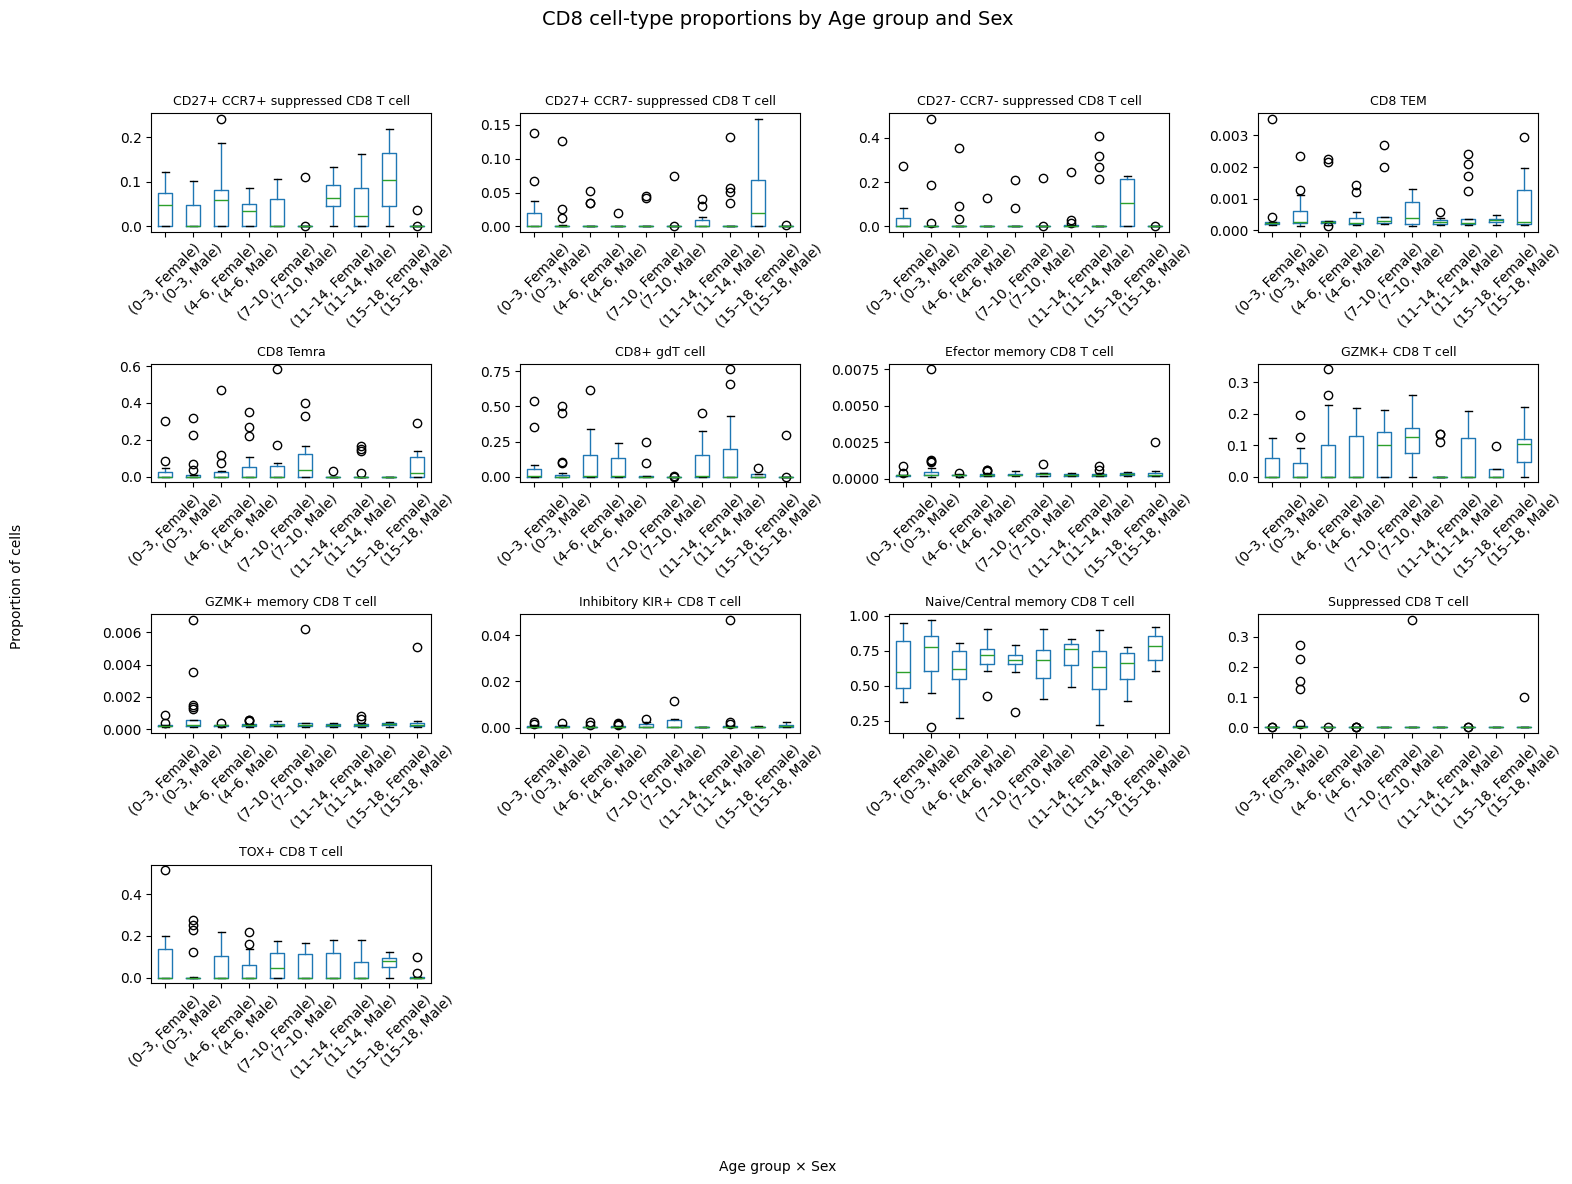

In [41]:
cell_types = sorted(df_age_sex["Cell Type"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df_age_sex[df_age_sex["Cell Type"] == cell]

    # grouped boxplot: Age_group on x, split by Sex
    # pandas boxplot supports grouping via `by=[...]`
    sub.boxplot(
        column="Proportion",
        by=["Age_group", "Child_sex"],
        grid=False,
        ax=ax,
        rot=45,
    )

    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty panels
for ax in axes[len(cell_types):]:
    ax.axis("off")

# IMPORTANT: pandas boxplot adds an automatic suptitle; remove it
plt.suptitle("")

fig.suptitle("CD8 cell-type proportions by Age group and Sex", fontsize=14)
fig.supxlabel("Age group × Sex", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()


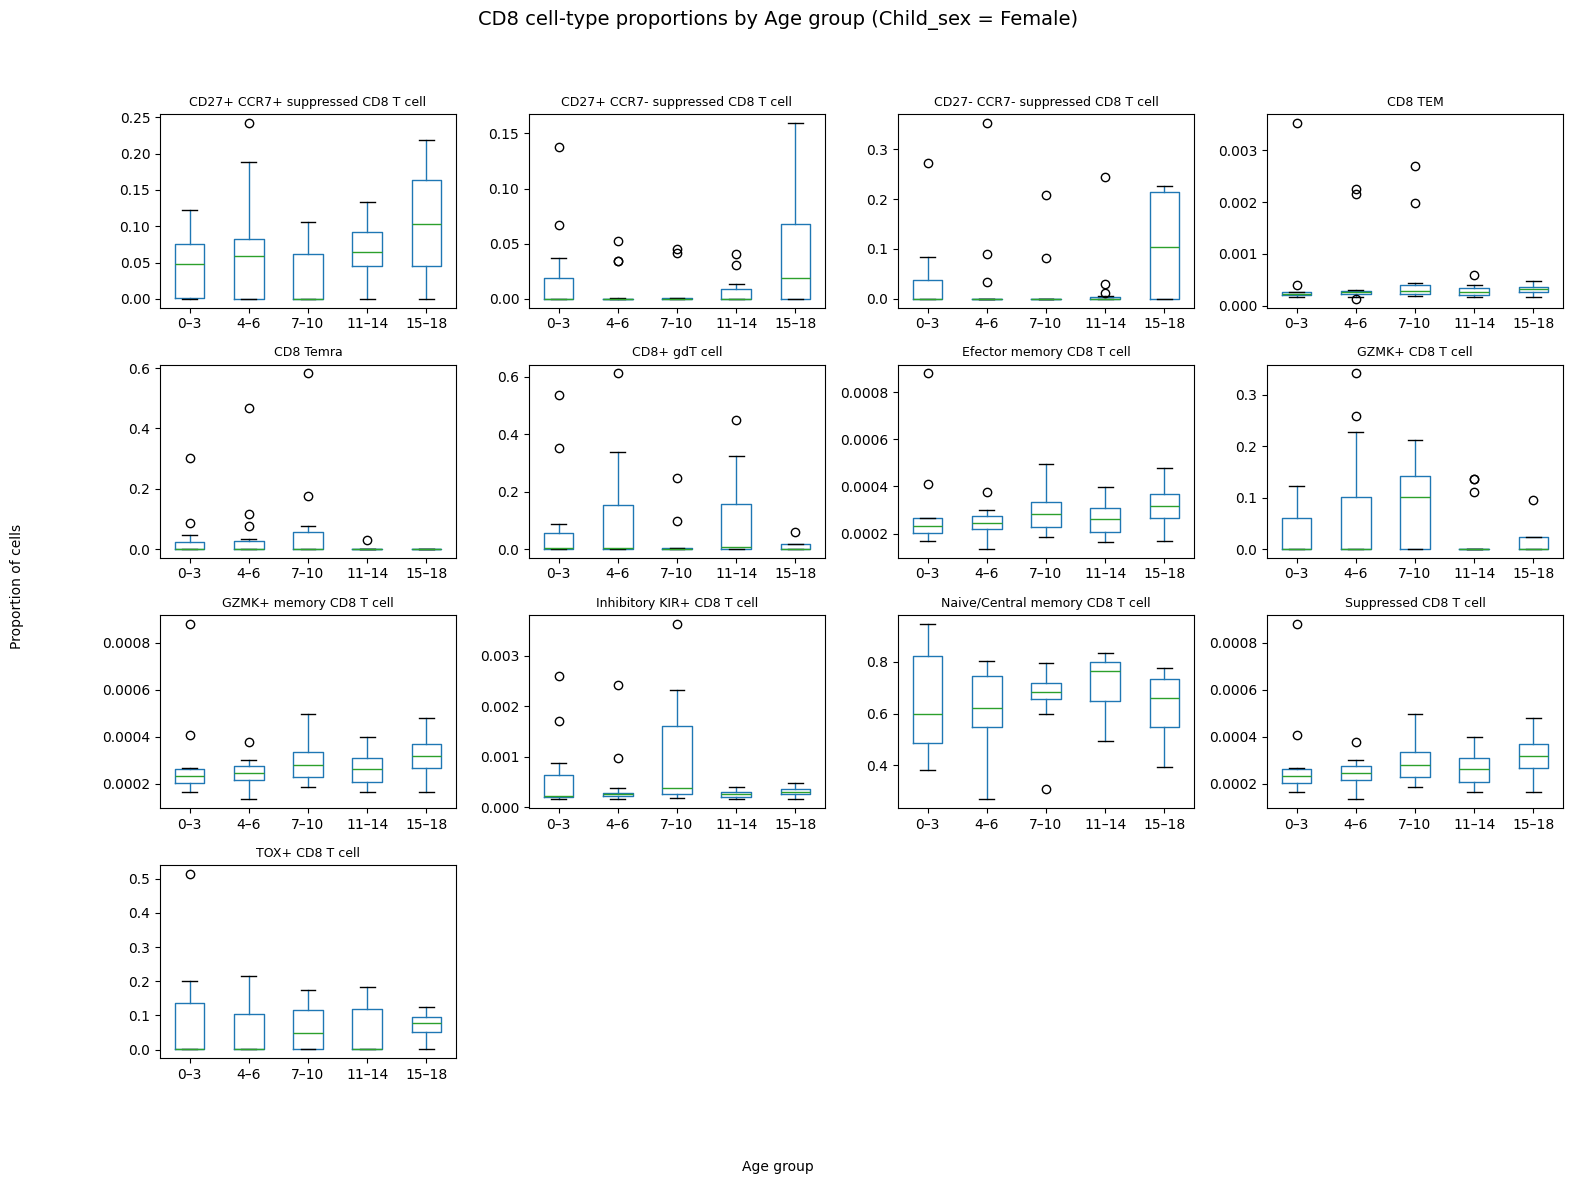

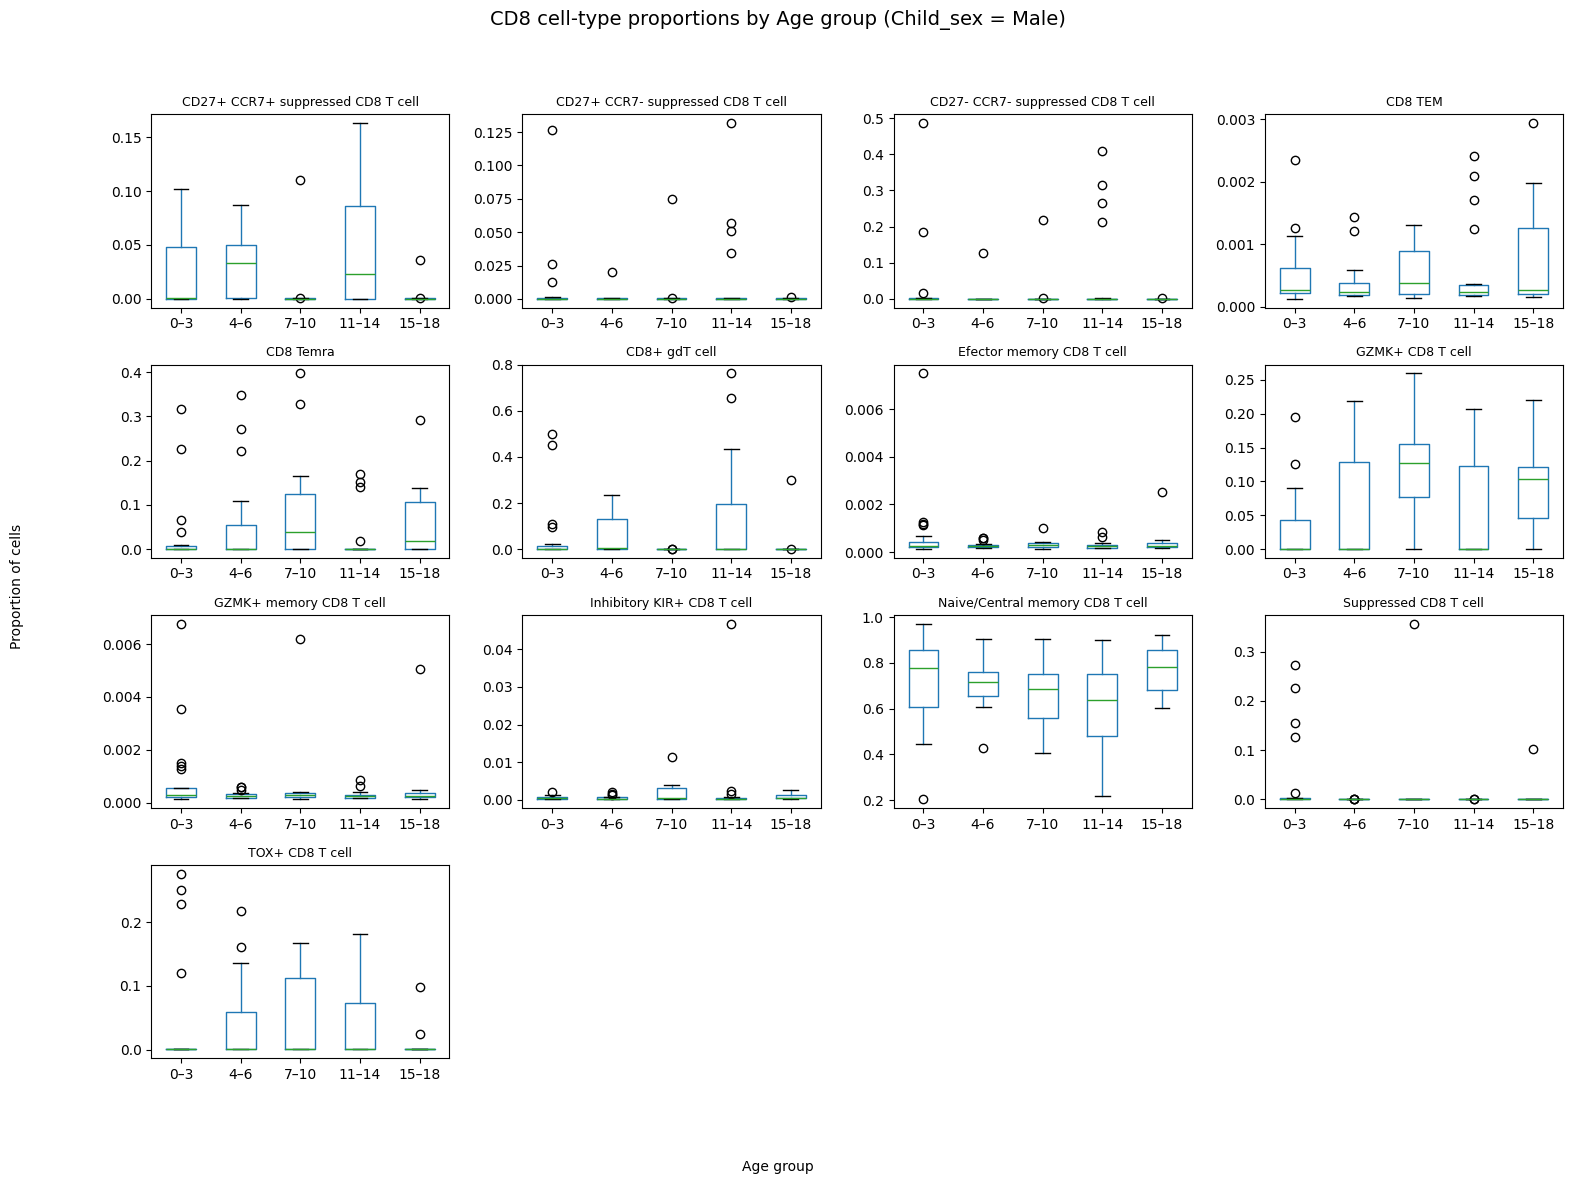

In [42]:
SEX_COL = "Child_sex"  

# get ordered sex levels robustly
sex_series = df_age_sex[SEX_COL]
sex_levels = (
    list(sex_series.cat.categories) if pd.api.types.is_categorical_dtype(sex_series)
    else sorted(sex_series.dropna().unique())
)

for sex in sex_levels:
    df_sex = df_age_sex[df_age_sex[SEX_COL] == sex].copy()

    cell_types = sorted(df_sex["Cell Type"].unique())
    n_cols = 4
    n_rows = math.ceil(len(cell_types) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, cell in zip(axes, cell_types):
        sub = df_sex[df_sex["Cell Type"] == cell]
        sub.boxplot(column="Proportion", by="Age_group", grid=False, ax=ax)

        ax.set_title(cell, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # turn off unused panels
    for ax in axes[len(cell_types):]:
        ax.axis("off")

    # remove pandas' automatic "by=..." title
    fig.suptitle(f"CD8 cell-type proportions by Age group ({SEX_COL} = {sex})", fontsize=14)
    fig.supxlabel("Age group", fontsize=10)
    fig.supylabel("Proportion of cells", fontsize=10)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
    plt.show()

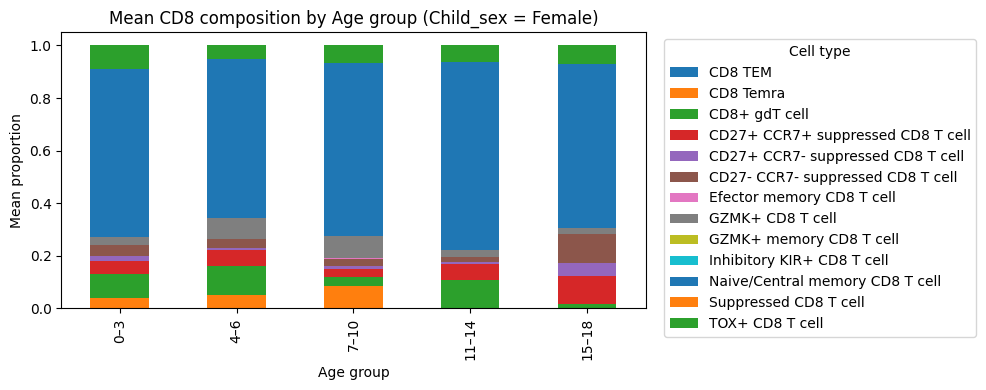

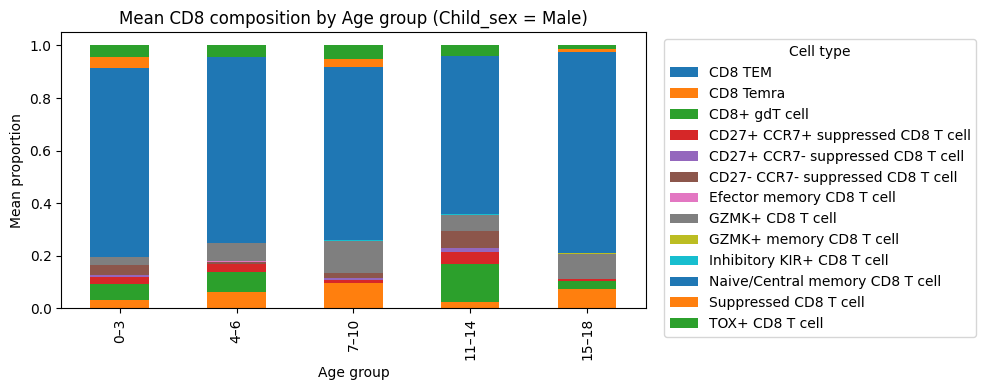

In [43]:
# mean composition per Age_group × Sex
props_age_sex = (
    props
    .join(meta[["Age_group", SEX_COL]])
    .groupby(["Age_group", SEX_COL])
    .mean()
)

for sex in props_age_sex.index.get_level_values(SEX_COL).unique():
    df_plot = props_age_sex.xs(sex, level=SEX_COL)

    ax = df_plot.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 4)
    )

    ax.set_xlabel("Age group")
    ax.set_ylabel("Mean proportion")
    ax.set_title(f"Mean CD8 composition by Age group ({SEX_COL} = {sex})")

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Cell type"
    )

    plt.tight_layout()
    plt.show()

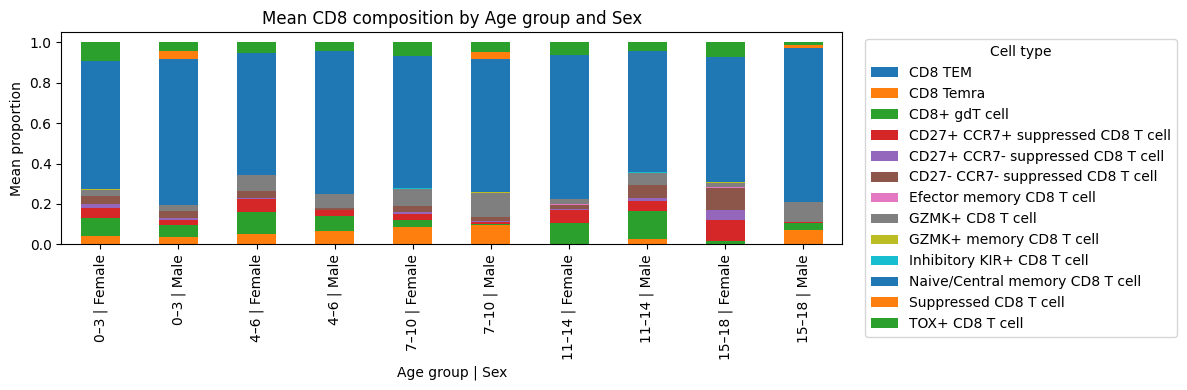

In [44]:
# combine index for plotting
props_age_sex.index = props_age_sex.index.map(
    lambda x: f"{x[0]} | {x[1]}"
)

ax = props_age_sex.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4)
)

ax.set_xlabel("Age group | Sex")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean CD8 composition by Age group and Sex")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Cell type"
)

plt.tight_layout()
plt.show()

In [45]:
effects = effects_cd8_age_sex.reset_index().copy()

effects["Covariate_type"] = effects["Covariate"].apply(
    lambda x: "Age_group" if str(x).startswith("Age_group") else "Sex")

In [46]:
effects.columns
effects[["Covariate","Cell Type","Covariate_type"]].head()

,Covariate,Cell Type,Covariate_type
0,Age_groupT.4–6,CD8 TEM,Age_group
1,Age_groupT.4–6,CD8 Temra,Age_group
2,Age_groupT.4–6,CD8+ gdT cell,Age_group
3,Age_groupT.4–6,CD27+ CCR7+ suppressed CD8 T cell,Age_group
4,Age_groupT.4–6,CD27+ CCR7- suppressed CD8 T cell,Age_group


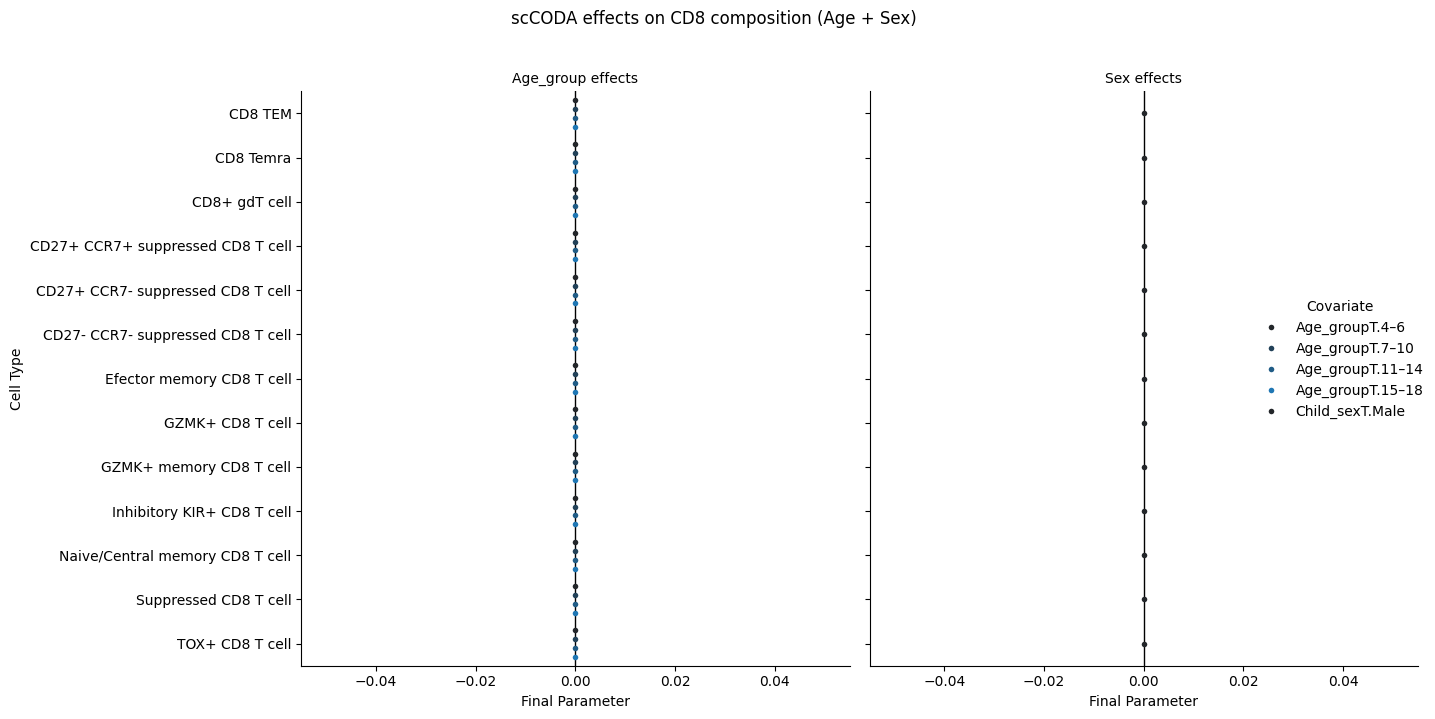

In [47]:
g = sns.FacetGrid(
    effects,
    col="Covariate_type",
    sharey=True,
    height=7,
    aspect=0.9
)

g.map_dataframe(
    sns.stripplot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)

for ax in g.axes.flat:
    ax.axvline(0, color="black", linewidth=1)

g.add_legend(title="Covariate")
g.set_titles("{col_name} effects")
g.fig.suptitle("scCODA effects on CD8 composition (Age + Sex)", y=1.02)

plt.tight_layout()
plt.show()

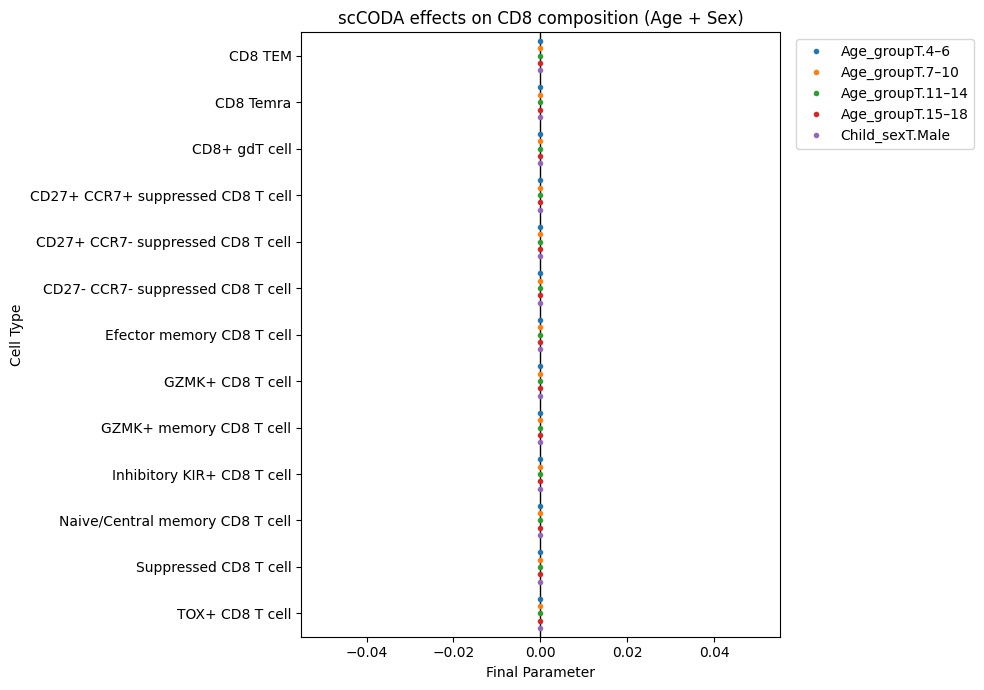

In [48]:
plt.figure(figsize=(10, 7))

sns.stripplot(
    data=effects_cd8_age_sex,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)

plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects on CD8 composition (Age + Sex)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [49]:
effects = effects_cd8_age_sex.copy()
print("index names:", effects.index.names)

index names: ['Covariate', 'Cell Type']


In [50]:
beta = effects["Final Parameter"].unstack(level=0)          # cols = covariate
ip   = effects["Inclusion probability"].unstack(level=0)    # cols = covariate

# now rows = Cell Type, cols = Covariate (flip if needed)
# If you prefer rows=Cell Type, cols=Covariate:
beta = beta.T if beta.index.name != "Cell Type" and beta.shape[0] < beta.shape[1] else beta
ip   = ip.T   if ip.index.name != "Cell Type" and ip.shape[0] < ip.shape[1] else ip

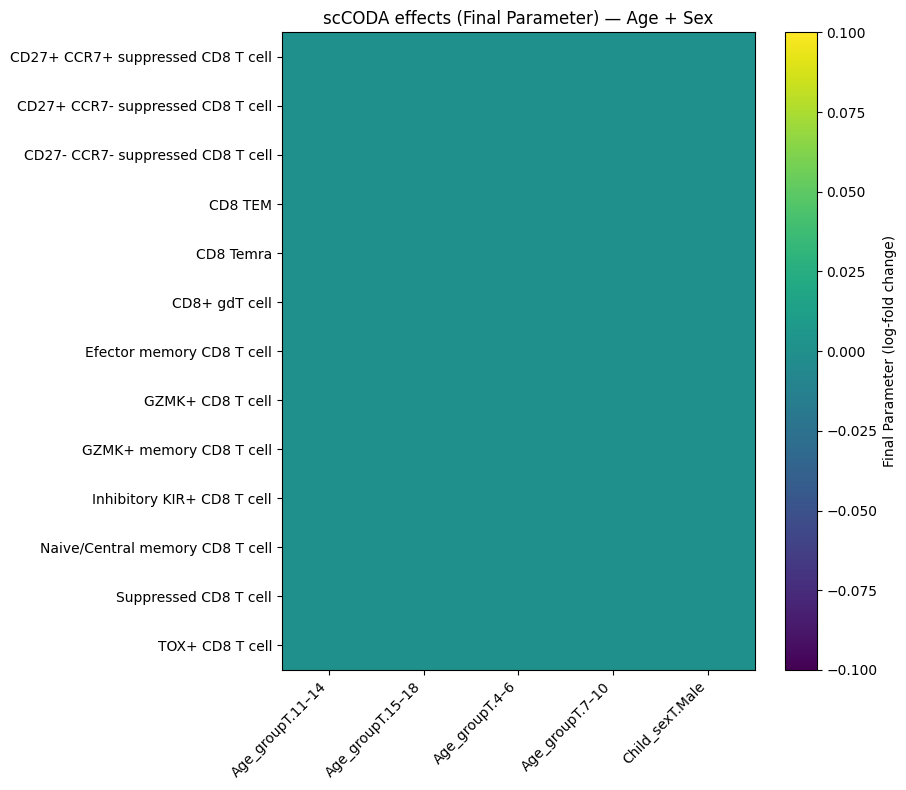

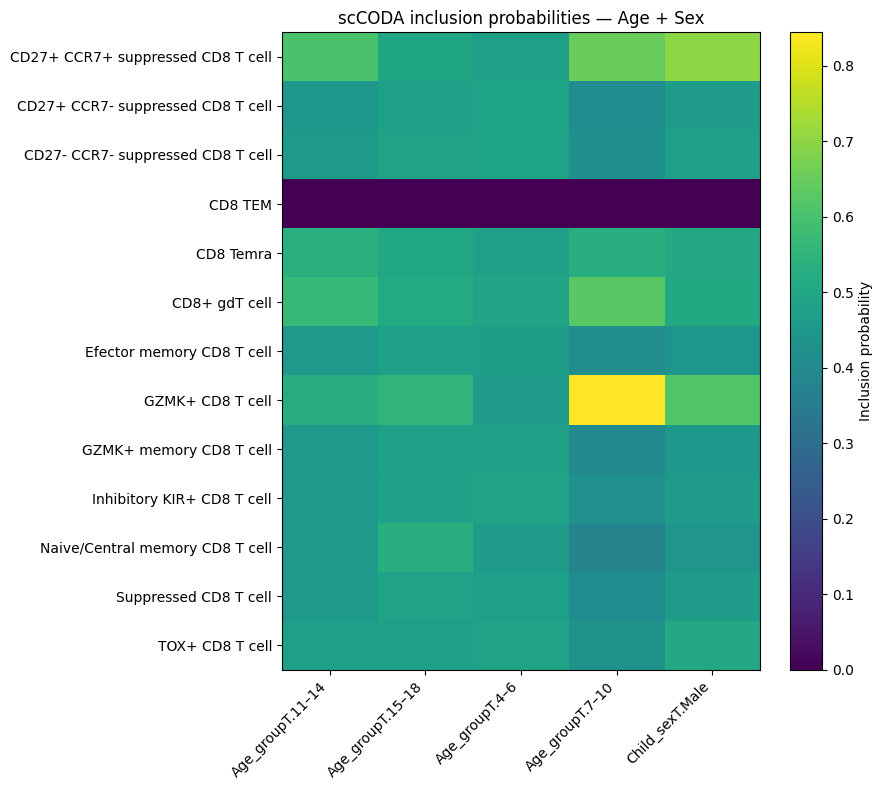

In [51]:
# Final Parameter heatmap
plt.figure(figsize=(9, 8))
plt.imshow(beta.values, aspect="auto")
plt.yticks(range(beta.shape[0]), beta.index)
plt.xticks(range(beta.shape[1]), beta.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter (log-fold change)")
plt.title("scCODA effects (Final Parameter) — Age + Sex")
plt.tight_layout()
plt.show()

# Inclusion probability heatmap
plt.figure(figsize=(9, 8))
plt.imshow(ip.values, aspect="auto")
plt.yticks(range(ip.shape[0]), ip.index)
plt.xticks(range(ip.shape[1]), ip.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities — Age + Sex")
plt.tight_layout()
plt.show()